# Subject-Generalising TDCS FoG Episode Detector

## Goal

Predict whether freezing of gait is occurring at each TDCS timestamp
and reconstruct complete episodes on genuinely unseen subjects.

### Identity mapping

`tdcsfog_metadata.csv` is the authoritative mapping from each recording
ID to its subject. All recordings belonging to one person stay in the
same train, validation, or test split.

## Setup

In [1]:
from pathlib import Path
import sys
import gc
import importlib
import numpy as np

print(f"Python executable: {sys.executable}")
print(f"NumPy version: {np.__version__}")
if int(np.__version__.split(".")[0]) >= 2:
    raise RuntimeError(
        "This notebook requires NumPy 1.26.x. Select the "
        "'Dissertation FoG (.venv)' kernel and restart the notebook."
    )

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython import get_ipython
from IPython.display import display

get_ipython().run_line_magic("matplotlib", "inline")

PROJECT_ROOT = next(
    candidate
    for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / "src" / "fog_pipeline.py").exists()
)
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

importlib.invalidate_caches()
import fog_pipeline as _fog_pipeline
_fog_pipeline = importlib.reload(_fog_pipeline)

from fog_pipeline import (
    ANY_FOG_COLUMN,
    FEATURE_COLUMNS,
    TARGET_COLUMNS,
    align_binary_predictions,
    assert_subject_disjoint,
    evaluate_episode_predictions,
    load_recordings,
    prepare_tabular_splits,
    select_episode_threshold,
    split_by_subject,
    split_summary,
)

RANDOM_STATE = 42
WINDOW_SIZE = 5
EDA_SAMPLE_SIZE = 200_000
EPOCHS = 40
EARLY_STOPPING_PATIENCE = 20
BATCH_SIZE = 4096
RUN_TRAINING = True
EPISODE_IOU_THRESHOLD = 0.25
# No temporal smoothing is imposed without validation evidence.
MERGE_GAP_SECONDS = 0.0
MIN_PREDICTED_EPISODE_SECONDS = 0.0
# Set a small integer for a quick smoke test, or None for the full dataset.
MAX_RECORDINGS = None
# Bounded smoke tests may not contain every rare label; full runs must.
REQUIRE_ALL_TARGETS = MAX_RECORDINGS is None

sns.set_theme(style="whitegrid", context="notebook")

Python executable: /home/rahul/.venvs/dissertation-gpu/bin/python
NumPy version: 1.26.4


## Data — map every recording to its subject

In [2]:
raw_data = load_recordings(
    recordings_dir=PROJECT_ROOT / "data" / "raw" / "train" / "tdcsfog",
    metadata_path=PROJECT_ROOT / "data" / "metadata" / "tdcsfog_metadata.csv",
    limit_recordings=MAX_RECORDINGS,
    filter_valid_task=False,
)
SAMPLING_RATE_HZ = 128.0
raw_data.head()

KeyboardInterrupt: 

### Dataset overview and class balance

,dataset_overview
rows,7062672
recordings,833
subjects_or_file_groups,62
time_min,0
time_max,97076


,missing_values
Time,0
AccV,0
AccML,0
AccAP,0
AnyFoG,0
StartHesitation,0
Turn,0
Walking,0
RecordingId,0
Subject,0


,count,mean,std,min,1%,25%,50%,75%,99%,max
Time,7062672.0,9289.467297,13998.925696,0.000000,84.000000,2119.000000,4310.000000,8433.000000,70068.000000,97076.000000
AccV,7062672.0,-9.306311,1.080174,-35.521118,-12.739630,-9.762402,-9.363524,-8.776814,-6.511659,20.906954
AccML,7062672.0,-0.201251,1.269525,-26.164398,-3.608931,-0.929545,-0.172225,0.575211,2.854258,27.484718
AccAP,7062672.0,1.808525,2.285849,-47.829639,-4.462803,0.567225,1.987101,3.449026,6.251663,30.337694
AnyFoG,7062672.0,0.310281,0.462608,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
StartHesitation,7062672.0,0.043155,0.203206,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
Turn,7062672.0,0.237698,0.425673,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
Walking,7062672.0,0.029428,0.169002,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000


,rows_per_recording
count,833.000000
mean,8478.597839
std,9260.027585
min,2359.000000
25%,4945.000000
50%,6290.000000
75%,8473.000000
max,97077.000000


,positive_rows,prevalence_percent
AnyFoG,2191410,31.028059
StartHesitation,304790,4.315506
Turn,1678782,23.769786
Walking,207838,2.942767


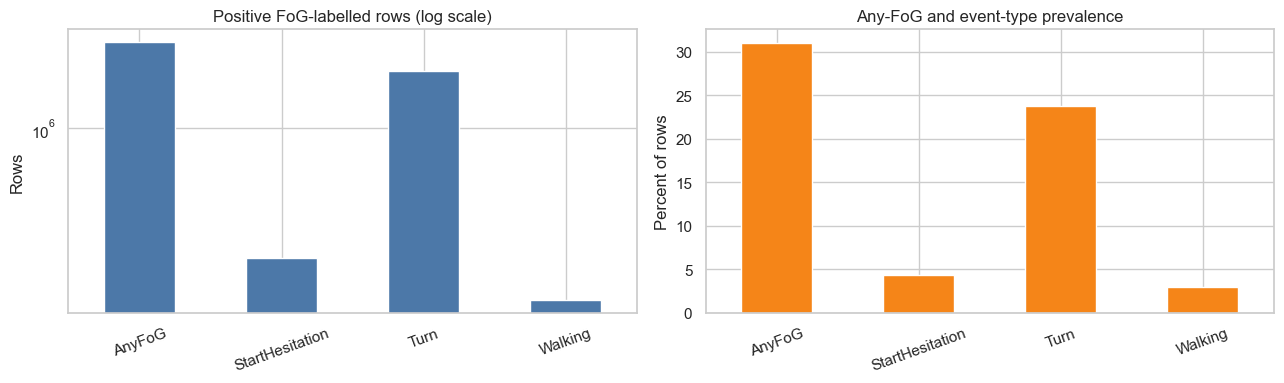

In [ ]:
overview = pd.Series(
    {
        "rows": len(raw_data),
        "recordings": raw_data["RecordingId"].nunique(),
        "subjects_or_file_groups": raw_data["Subject"].nunique(),
        "time_min": raw_data["Time"].min(),
        "time_max": raw_data["Time"].max(),
    },
    name="dataset_overview",
)
display(overview.to_frame())

missing_summary = raw_data[
    [
        "Time",
        *FEATURE_COLUMNS[:3],
        ANY_FOG_COLUMN,
        *TARGET_COLUMNS,
        "RecordingId",
        "Subject",
    ]
].isna().sum().rename("missing_values")
display(missing_summary.to_frame())

numeric_summary = raw_data[
    ["Time", *FEATURE_COLUMNS[:3], ANY_FOG_COLUMN, *TARGET_COLUMNS]
].describe(percentiles=[0.01, 0.25, 0.50, 0.75, 0.99]).T
display(numeric_summary)

recording_lengths = raw_data.groupby("RecordingId", observed=True).size()
display(
    recording_lengths.describe().rename("rows_per_recording").to_frame()
)

event_columns = [ANY_FOG_COLUMN, *TARGET_COLUMNS]
event_summary = pd.DataFrame(
    {
        "positive_rows": raw_data.loc[:, event_columns].sum(),
        "prevalence_percent": raw_data.loc[:, event_columns].mean() * 100,
    }
)
display(event_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
event_summary["positive_rows"].plot.bar(ax=axes[0], color="#4c78a8")
axes[0].set_yscale("log")
axes[0].set_title("Positive FoG-labelled rows (log scale)")
axes[0].set_ylabel("Rows")
event_summary["prevalence_percent"].plot.bar(ax=axes[1], color="#f58518")
axes[1].set_title("Any-FoG and event-type prevalence")
axes[1].set_ylabel("Percent of rows")
for axis in axes:
    axis.tick_params(axis="x", rotation=20)
plt.tight_layout()
plt.show()

### Representative sensor and event window

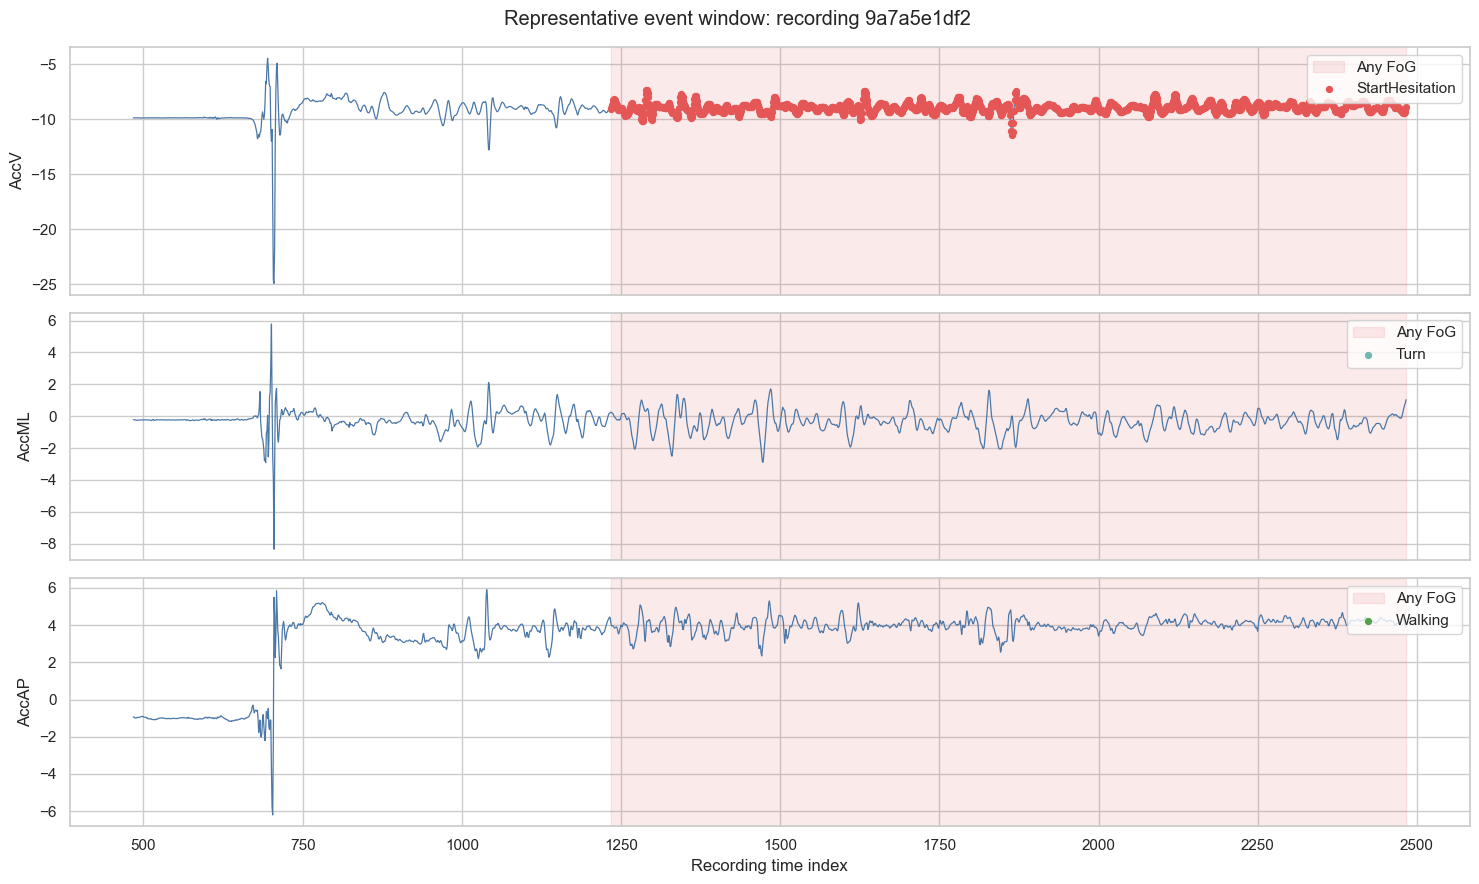

In [ ]:
recording_event_totals = raw_data.groupby(
    "RecordingId", observed=True
)[list(TARGET_COLUMNS)].sum()
sample_recording_id = recording_event_totals.sum(axis=1).idxmax()
sample_recording = raw_data.loc[
    raw_data["RecordingId"] == sample_recording_id
].sort_values("Time", kind="stable")

event_positions = np.flatnonzero(
    sample_recording.loc[:, TARGET_COLUMNS].any(axis=1).to_numpy()
)
centre = int(event_positions[0]) if len(event_positions) else len(sample_recording) // 2
window_start = max(0, centre - 750)
window_end = min(len(sample_recording), centre + 1250)
plot_window = sample_recording.iloc[window_start:window_end]

sensor_event_pairs = [
    ("AccV", "StartHesitation", "#e45756"),
    ("AccML", "Turn", "#72b7b2"),
    ("AccAP", "Walking", "#54a24b"),
]
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
for axis, (sensor, target, colour) in zip(axes, sensor_event_pairs):
    sensor_values = plot_window[sensor].copy()
    positive_time_steps = plot_window["Time"].diff().dropna()
    positive_time_steps = positive_time_steps.loc[positive_time_steps > 0]
    typical_step = float(positive_time_steps.median()) if len(positive_time_steps) else 1.0
    sensor_values.loc[plot_window["Time"].diff() > 5 * typical_step] = np.nan
    axis.plot(plot_window["Time"], sensor_values, linewidth=0.9, color="#4c78a8")
    axis.fill_between(
        plot_window["Time"],
        0,
        1,
        where=plot_window[ANY_FOG_COLUMN].astype(bool),
        transform=axis.get_xaxis_transform(),
        step="post",
        color="#e45756",
        alpha=0.12,
        label="Any FoG",
    )
    events = plot_window.loc[plot_window[target] == 1]
    axis.scatter(events["Time"], events[sensor], s=18, color=colour, label=target, zorder=3)
    axis.set_ylabel(sensor)
    axis.legend(loc="upper right")
axes[-1].set_xlabel("Recording time index")
fig.suptitle(f"Representative event window: recording {sample_recording_id}")
plt.tight_layout()
plt.show()

### Correlations, event-conditioned means, and label combinations

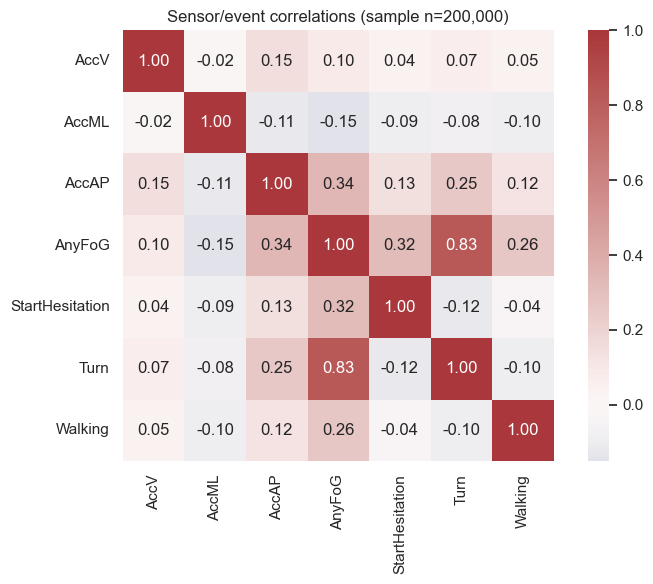

AccV     AccML     AccAP
target          state                              
AnyFoG          0     -9.372777 -0.075010  1.295267
                1     -9.147614 -0.486605  2.957229
StartHesitation 0     -9.312174 -0.177350  1.746207
                1     -9.096191 -0.766869  3.256950
Turn            0     -9.343178 -0.147134  1.488344
                1     -9.173437 -0.381661  2.848033
Walking         0     -9.311568 -0.181069  1.763436
                1     -9.015304 -0.919785  3.396077

,StartHesitation,Turn,Walking,rows
0,0,0,0,4871262
1,0,1,0,1678782
2,1,0,0,304790
3,0,0,1,207838


In [ ]:
eda_sample = raw_data.sample(
    n=min(EDA_SAMPLE_SIZE, len(raw_data)),
    random_state=RANDOM_STATE,
)
correlation_columns = [*FEATURE_COLUMNS[:3], ANY_FOG_COLUMN, *TARGET_COLUMNS]
correlation_matrix = eda_sample.loc[:, correlation_columns].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    square=True,
)
plt.title(f"Sensor/event correlations (sample n={len(eda_sample):,})")
plt.tight_layout()
plt.show()

sensor_means = []
for target in (ANY_FOG_COLUMN, *TARGET_COLUMNS):
    grouped_means = eda_sample.groupby(target, observed=True)[list(FEATURE_COLUMNS[:3])].mean()
    grouped_means["target"] = target
    grouped_means["state"] = grouped_means.index.astype(int)
    sensor_means.append(grouped_means.reset_index(drop=True))
sensor_means = pd.concat(sensor_means, ignore_index=True)
display(sensor_means.set_index(["target", "state"]))

cooccurrence = raw_data.loc[:, TARGET_COLUMNS].value_counts().rename("rows").reset_index()
display(cooccurrence.head(10))

## Methods — subject-disjoint train, validation, and test splits

In [ ]:
subject_splits = split_by_subject(
    raw_data,
    test_size=0.20,
    validation_size=0.20,
    random_state=RANDOM_STATE,
    require_all_targets=REQUIRE_ALL_TARGETS,
)
print("Selected split seed:", subject_splits.random_state)
split_summary(subject_splits)

Selected split seed: 42


,subjects,recordings,rows,StartHesitation_rate,Turn_rate,Walking_rate,AnyFoG_rate
split,,,,,,,
train,36,469,3477044,0.013893,0.191976,0.010530,0.216398
validation,13,182,1320814,0.005732,0.205099,0.004933,0.215765
test,13,182,2264814,0.109905,0.326903,0.072725,0.509533


## Checks — prove subjects, recordings, and labels cannot leak

In [ ]:
assert_subject_disjoint(subject_splits)
assert set(TARGET_COLUMNS).isdisjoint(FEATURE_COLUMNS)
assert ANY_FOG_COLUMN not in FEATURE_COLUMNS
print("Real TDCS subjects are disjoint across all splits.")
print("Model features:", list(FEATURE_COLUMNS))

Real TDCS subjects are disjoint across all splits.
Model features: ['AccV', 'AccML', 'AccAP', 'Rolling_AccV_Mean', 'Rolling_AccV_Std', 'Rolling_AccML_Mean', 'Rolling_AccML_Std', 'Rolling_AccAP_Mean', 'Rolling_AccAP_Std', 'Acc_Magnitude']


,subjects,recordings,rows,StartHesitation_rate,Turn_rate,Walking_rate,AnyFoG_rate
split,,,,,,,
train,36,469,3477044,0.013893,0.191976,0.010530,0.216398
validation,13,182,1320814,0.005732,0.205099,0.004933,0.215765
test,13,182,2264814,0.109905,0.326903,0.072725,0.509533


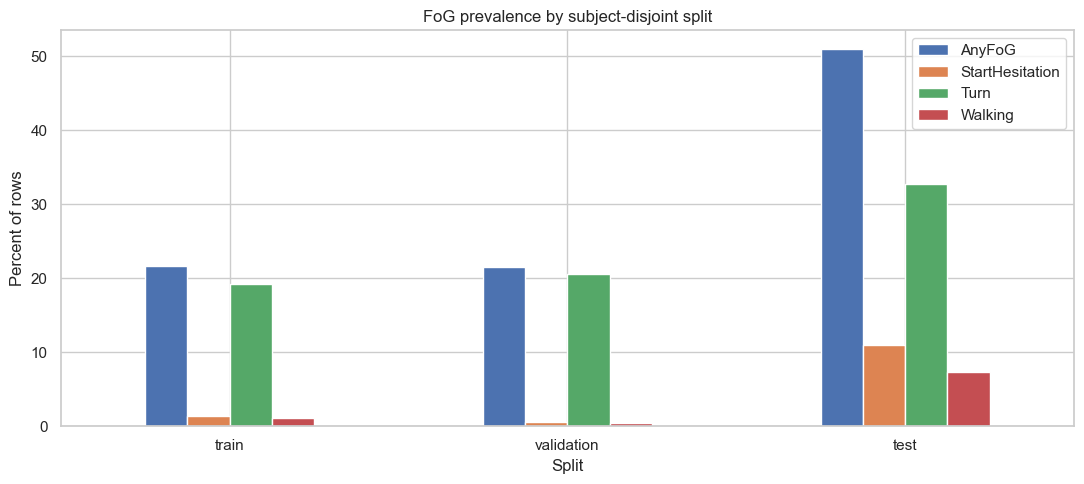

In [ ]:
split_table = split_summary(subject_splits)
display(split_table)

rate_targets = [ANY_FOG_COLUMN, *TARGET_COLUMNS]
rate_columns = [f"{target}_rate" for target in rate_targets]
rate_plot = split_table.loc[:, rate_columns].rename(
    columns={f"{target}_rate": target for target in rate_targets}
) * 100
rate_plot.plot.bar(figsize=(11, 5))
plt.title("FoG prevalence by subject-disjoint split")
plt.ylabel("Percent of rows")
plt.xlabel("Split")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Features — fit imputation and scaling on training subjects only

In [ ]:
del raw_data
gc.collect()
prepared = prepare_tabular_splits(
    subject_splits,
    window_size=WINDOW_SIZE,
)
del subject_splits
gc.collect()

pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "samples": [
            len(prepared.X_train),
            len(prepared.X_validation),
            len(prepared.X_test),
        ],
    }
)

,split,samples
0,train,3477044
1,validation,1320814
2,test,2264814


## Model — train one general model

In [ ]:
model = None
history = None

if RUN_TRAINING:
    import tensorflow as tf

    tf.keras.utils.set_random_seed(RANDOM_STATE)
    fog_train = prepared.y_any_fog_train
    fog_validation = prepared.y_any_fog_validation
    fog_negatives = float((1.0 - fog_train).sum())
    fog_positives = float(fog_train.sum())
    fog_positive_weight = float(
        np.clip(fog_negatives / max(fog_positives, 1.0), 1.0, 200.0)
    )
    type_negatives = (1.0 - prepared.y_train).sum(axis=0)
    type_positives = prepared.y_train.sum(axis=0)
    type_positive_weights = np.clip(
        type_negatives / np.maximum(type_positives, 1.0), 1.0, 200.0
    )
    print(f"Any-FoG positive-class loss weight: {fog_positive_weight:.2f}")
    print(
        "Auxiliary event-type weights:",
        dict(zip(TARGET_COLUMNS, type_positive_weights.round(2))),
    )

    def make_weighted_binary_crossentropy(positive_weights):
        weights = tf.constant(positive_weights, dtype=tf.float32)

        def weighted_binary_crossentropy(y_true, y_pred):
            y_pred = tf.clip_by_value(
                y_pred,
                tf.keras.backend.epsilon(),
                1.0 - tf.keras.backend.epsilon(),
            )
            loss = -(
                weights * y_true * tf.math.log(y_pred)
                + (1.0 - y_true) * tf.math.log(1.0 - y_pred)
            )
            return tf.reduce_mean(loss)

        return weighted_binary_crossentropy

    inputs = tf.keras.layers.Input(shape=(len(FEATURE_COLUMNS),), name="sensor_features")
    shared = tf.keras.layers.Dense(128, activation="relu")(inputs)
    shared = tf.keras.layers.Dense(128, activation="relu")(shared)
    shared = tf.keras.layers.Dense(64, activation="relu")(shared)
    fog_output = tf.keras.layers.Dense(1, activation="sigmoid", name="fog")(shared)
    event_type_output = tf.keras.layers.Dense(
        len(TARGET_COLUMNS), activation="sigmoid", name="event_type"
    )(shared)
    model = tf.keras.Model(
        inputs=inputs,
        outputs={"fog": fog_output, "event_type": event_type_output},
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss={
            "fog": make_weighted_binary_crossentropy(fog_positive_weight),
            "event_type": make_weighted_binary_crossentropy(type_positive_weights),
        },
        loss_weights={"fog": 1.0, "event_type": 0.2},
        metrics={
            "fog": [
                tf.keras.metrics.AUC(curve="PR", name="pr_auc"),
                tf.keras.metrics.Precision(name="precision"),
                tf.keras.metrics.Recall(name="recall"),
                tf.keras.metrics.BinaryAccuracy(name="binary_accuracy"),
            ],
            "event_type": [
                tf.keras.metrics.AUC(
                    curve="PR",
                    multi_label=True,
                    num_labels=len(TARGET_COLUMNS),
                    name="pr_auc",
                )
            ],
        },
    )
    history = model.fit(
        prepared.X_train,
        {"fog": fog_train, "event_type": prepared.y_train},
        validation_data=(
            prepared.X_validation,
            {"fog": fog_validation, "event_type": prepared.y_validation},
        ),
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        callbacks=[
            
        ],
        verbose=2,
    )
else:
    print("Training is disabled. Set RUN_TRAINING=True after reviewing the split summary.")

Any-FoG positive-class loss weight: 3.62
Auxiliary event-type weights: {'StartHesitation': 70.98, 'Turn': 4.21, 'Walking': 93.97}
Epoch 1/40
849/849 - 13s - 15ms/step - event_type_loss: 1.0740 - event_type_pr_auc: 0.1639 - fog_binary_accuracy: 0.6398 - fog_loss: 0.8946 - fog_pr_auc: 0.4787 - fog_precision: 0.3471 - fog_recall: 0.7542 - loss: 1.1094 - val_event_type_loss: 0.9402 - val_event_type_pr_auc: 0.1378 - val_fog_binary_accuracy: 0.6740 - val_fog_loss: 0.9439 - val_fog_pr_auc: 0.4146 - val_fog_precision: 0.3511 - val_fog_recall: 0.6023 - val_loss: 1.1332
Epoch 2/40
849/849 - 8s - 9ms/step - event_type_loss: 0.9851 - event_type_pr_auc: 0.1925 - fog_binary_accuracy: 0.6799 - fog_loss: 0.8400 - fog_pr_auc: 0.5434 - fog_precision: 0.3783 - fog_recall: 0.7447 - loss: 1.0370 - val_event_type_loss: 0.9646 - val_event_type_pr_auc: 0.1455 - val_fog_binary_accuracy: 0.6563 - val_fog_loss: 0.9226 - val_fog_pr_auc: 0.4321 - val_fog_precision: 0.3454 - val_fog_recall: 0.6624 - val_loss: 1.116

### Learning curves

,event_type_loss,event_type_pr_auc,fog_binary_accuracy,fog_loss,fog_pr_auc,fog_precision,fog_recall,loss,val_event_type_loss,val_event_type_pr_auc,val_fog_binary_accuracy,val_fog_loss,val_fog_pr_auc,val_fog_precision,val_fog_recall,val_loss
0,1.074015,0.163886,0.639760,0.894585,0.478706,0.347064,0.754221,1.109391,0.940233,0.137753,0.674044,0.943925,0.414650,0.351139,0.602330,1.133226
1,0.985081,0.192481,0.679906,0.840027,0.543410,0.378290,0.744691,1.037038,0.964638,0.145496,0.656309,0.922611,0.432098,0.345417,0.662417,1.116787
2,0.951674,0.205839,0.683094,0.830693,0.557304,0.381694,0.749242,1.021023,0.992981,0.149329,0.661125,0.914067,0.440503,0.350310,0.667646,1.113928
3,0.930516,0.215357,0.687514,0.824785,0.565535,0.385533,0.747763,1.010883,1.013826,0.148529,0.662731,0.915246,0.434953,0.351326,0.665354,1.119256
4,0.920357,0.219227,0.690688,0.820077,0.571414,0.388371,0.746903,1.004142,1.032383,0.149211,0.670853,0.919181,0.433390,0.355835,0.648518,1.126927
5,0.914060,0.220678,0.692665,0.816622,0.575879,0.390138,0.746151,0.999429,1.047719,0.148081,0.678265,0.924665,0.431079,0.359099,0.625857,1.135491
6,0.908223,0.223270,0.694699,0.813978,0.578947,0.392002,0.745591,0.995618,1.054315,0.151691,0.699031,0.925218,0.439248,0.374194,0.587284,1.137422
7,0.903428,0.228419,0.695849,0.812003,0.581707,0.393076,0.745381,0.992684,1.066528,0.153042,0.692619,0.925741,0.441716,0.369616,0.601853,1.140370
8,0.898722,0.236779,0.697177,0.809918,0.584457,0.394314,0.745040,0.989657,1.064337,0.152367,0.693200,0.928972,0.439313,0.369683,0.598453,1.143183
9,0.894495,0.246437,0.698312,0.807909,0.587034,0.395435,0.745252,0.986801,1.063891,0.152279,0.695161,0.933401,0.438221,0.370832,0.592607,1.147533


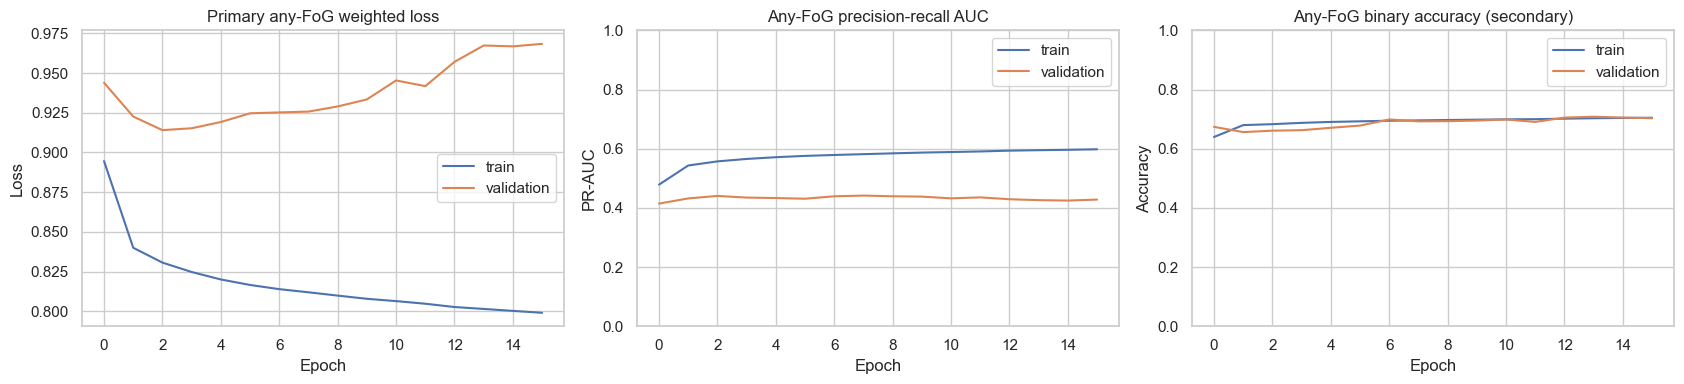

In [ ]:
if history is not None:
    history_frame = pd.DataFrame(history.history)
    display(history_frame)

    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    axes[0].plot(history_frame["fog_loss"], label="train")
    axes[0].plot(history_frame["val_fog_loss"], label="validation")
    axes[0].set_title("Primary any-FoG weighted loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()

    axes[1].plot(history_frame["fog_pr_auc"], label="train")
    axes[1].plot(history_frame["val_fog_pr_auc"], label="validation")
    axes[1].set_title("Any-FoG precision-recall AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("PR-AUC")
    axes[1].set_ylim(0, 1)
    axes[1].legend()

    axes[2].plot(history_frame["fog_binary_accuracy"], label="train")
    axes[2].plot(
        history_frame["val_fog_binary_accuracy"], label="validation"
    )
    axes[2].set_title("Any-FoG binary accuracy (secondary)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Accuracy")
    axes[2].set_ylim(0, 1)
    axes[2].legend()
    plt.tight_layout()
    plt.show()
else:
    print("Learning curves are unavailable because training is disabled.")

## Final test — detect episodes on unseen subjects

Validation-selected any-FoG threshold: 0.05


,threshold,episode_precision,episode_recall,episode_f1,false_alarms_per_minute,mean_duration_iou,true_episodes,predicted_episodes,matched_episodes
0,0.05,0.018372,0.306050,0.034663,26.718069,0.491147,281,4681,86
1,0.10,0.016522,0.576512,0.032124,56.070151,0.500176,281,9805,162
2,0.15,0.013336,0.736655,0.026198,89.050540,0.495864,281,15522,207
3,0.20,0.010156,0.790036,0.020054,125.810417,0.493795,281,21859,222
4,0.25,0.006648,0.672598,0.013165,164.215824,0.495565,281,28431,189
5,0.30,0.004438,0.555160,0.008806,203.464349,0.464020,281,35148,156
6,0.35,0.002807,0.416370,0.005577,241.642987,0.431106,281,41675,117
7,0.40,0.001731,0.291815,0.003442,274.919921,0.411195,281,47363,82
8,0.45,0.000883,0.160142,0.001756,296.131567,0.406192,281,50974,45
9,0.50,0.000487,0.088968,0.000968,298.585327,0.445767,281,51376,25


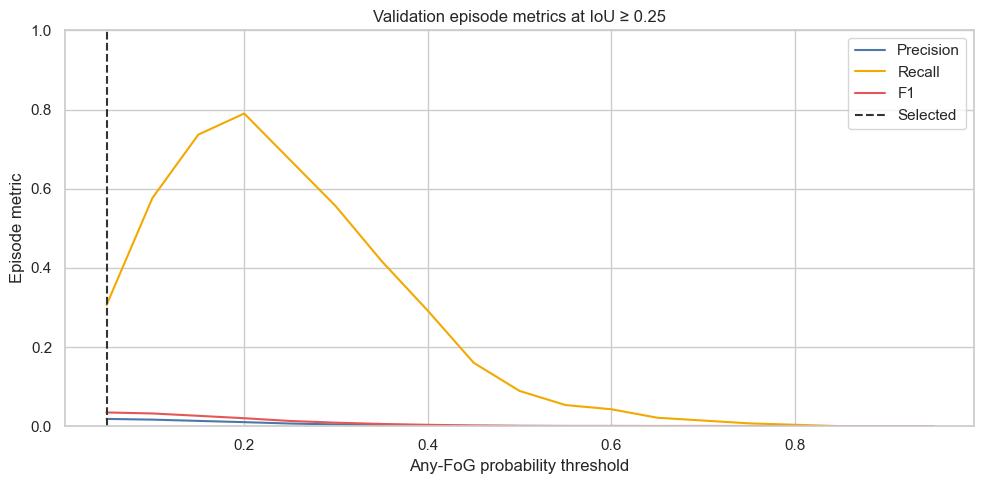

,fog_loss,any_fog_prevalence,average_precision,balanced_accuracy,precision,recall,f1
split,,,,,,,
train,0.809825,0.216398,0.586117,0.588759,0.251416,0.998723,0.401707
validation,0.925741,0.215765,0.441734,0.578341,0.246118,0.996316,0.394728
test,2.462842,0.509533,0.533626,0.606279,0.569783,0.985911,0.722193


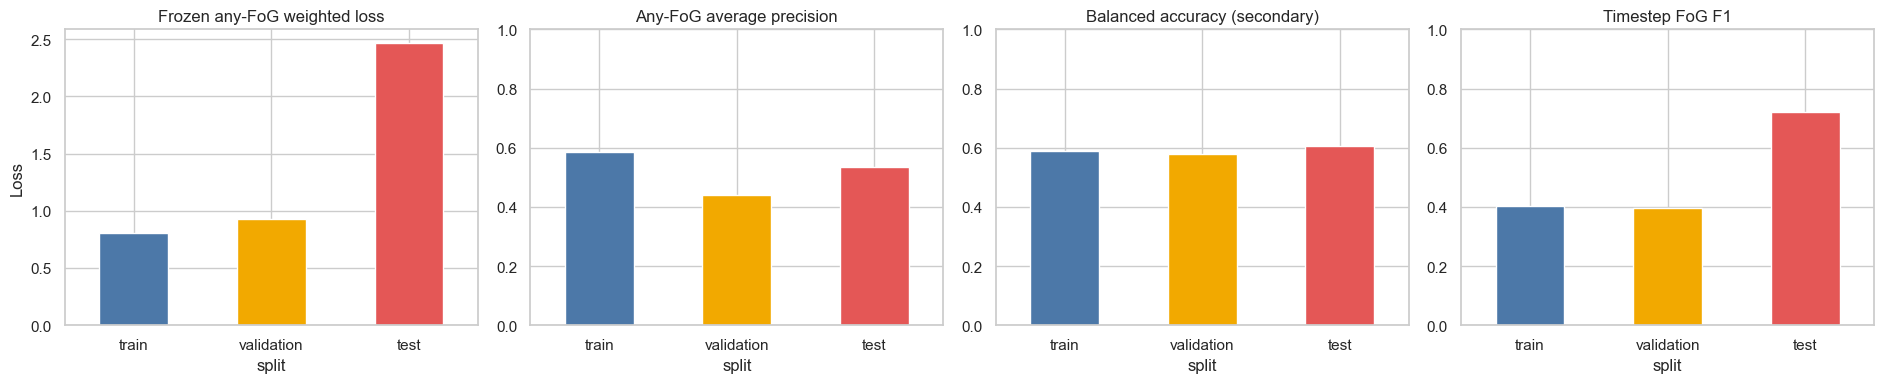

,held_out_test
threshold_selected_on_validation,0.050000
positive_prevalence,0.509533
average_precision,0.533626
balanced_accuracy,0.606279
precision,0.569783
recall,0.985911
f1,0.722193


,held_out_test
true_episodes,275.000000
predicted_episodes,14258.000000
matched_episodes,142.000000
false_positive_episodes,14116.000000
missed_episodes,133.000000
episode_precision,0.009959
episode_recall,0.516364
episode_f1,0.019542
false_alarms_per_minute,47.867454
mean_onset_delay_seconds,-1.253246


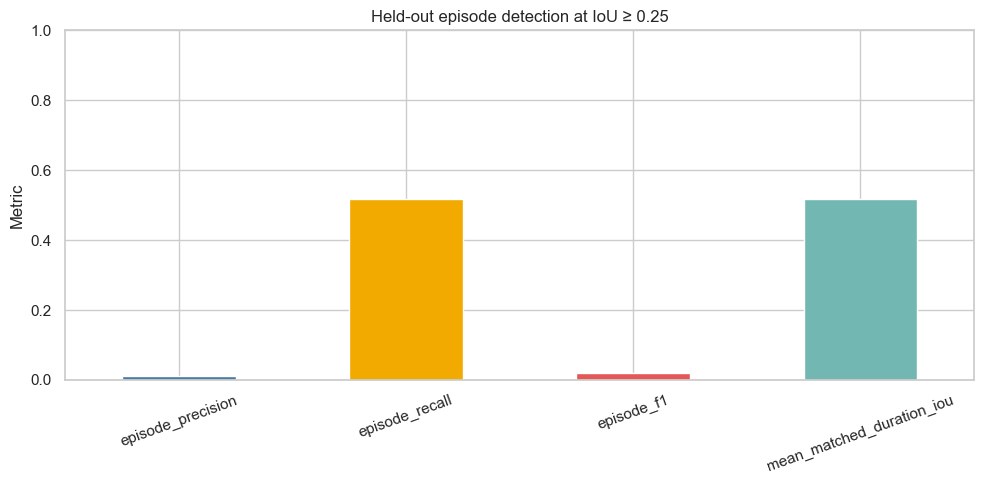

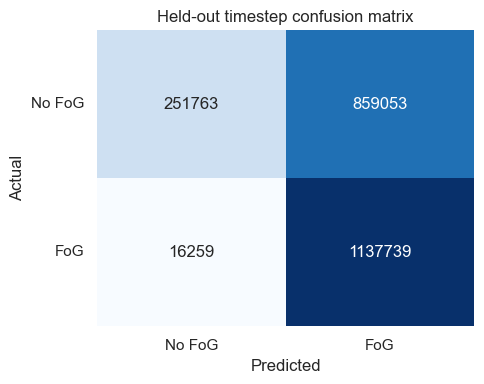

,threshold,positive_prevalence,average_precision,precision,recall,f1
target,,,,,,
StartHesitation,0.876372,0.109905,0.104123,0.000000,0.000000,0.000000
Turn,0.487756,0.326903,0.344359,0.321465,0.231483,0.269152
Walking,0.858533,0.072725,0.066107,0.091896,0.003442,0.006636


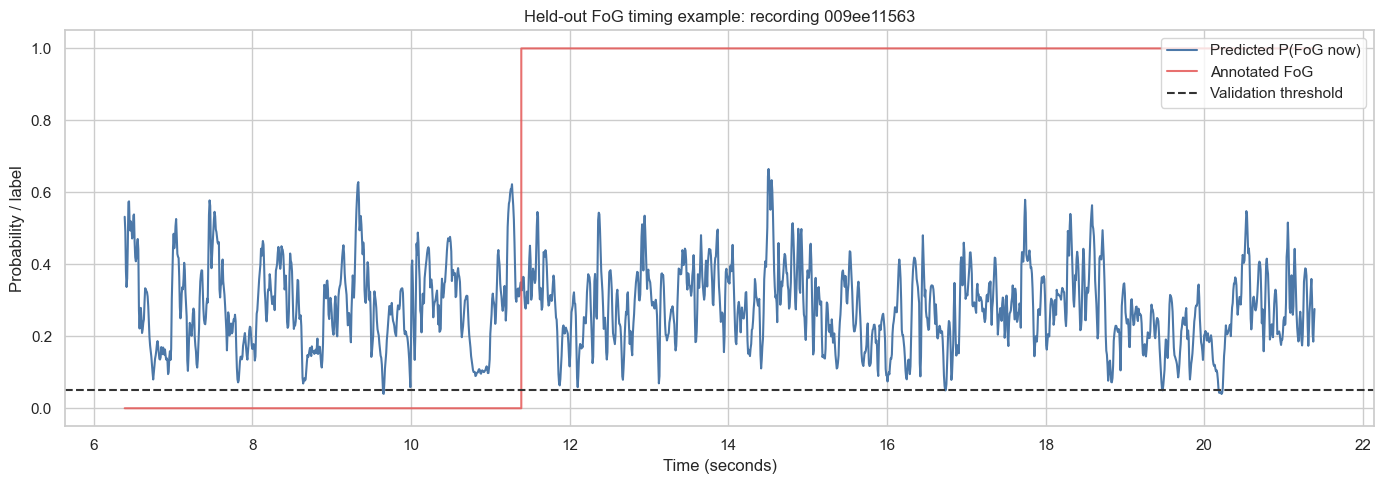

In [ ]:
if model is not None:
    from sklearn.metrics import (
        average_precision_score,
        balanced_accuracy_score,
        confusion_matrix,
        f1_score,
        precision_recall_curve,
        precision_score,
        recall_score,
    )

    def unpack_model_outputs(outputs):
        if isinstance(outputs, dict):
            return outputs["fog"], outputs["event_type"]
        output_by_name = dict(zip(model.output_names, outputs))
        return output_by_name["fog"], output_by_name["event_type"]

    validation_outputs = model.predict(
        prepared.X_validation,
        batch_size=BATCH_SIZE,
        verbose=0,
    )
    validation_fog_probabilities, validation_type_probabilities = unpack_model_outputs(
        validation_outputs
    )
    decision_threshold, threshold_search = select_episode_threshold(
        prepared.alignment_splits.validation,
        prepared.y_any_fog_validation,
        validation_fog_probabilities,
        sampling_rate_hz=SAMPLING_RATE_HZ,
        thresholds=np.linspace(0.05, 0.95, 19),
        minimum_iou=EPISODE_IOU_THRESHOLD,
        merge_gap_seconds=MERGE_GAP_SECONDS,
        minimum_predicted_duration_seconds=MIN_PREDICTED_EPISODE_SECONDS,
    )
    print(f"Validation-selected any-FoG threshold: {decision_threshold:.2f}")
    display(threshold_search)

    plt.figure(figsize=(10, 5))
    for metric, colour in (
        ("episode_precision", "#4c78a8"),
        ("episode_recall", "#f2a900"),
        ("episode_f1", "#e45756"),
    ):
        plt.plot(
            threshold_search["threshold"],
            threshold_search[metric],
            label=metric.replace("episode_", "").title(),
            color=colour,
        )
    plt.axvline(decision_threshold, color="#333333", linestyle="--", label="Selected")
    plt.title(f"Validation episode metrics at IoU ≥ {EPISODE_IOU_THRESHOLD:.2f}")
    plt.xlabel("Any-FoG probability threshold")
    plt.ylabel("Episode metric")
    plt.ylim(0, 1)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Freeze the model and validation-selected threshold before examining test.
    split_evaluations = []
    split_probabilities = {}
    for split_name, X_values, y_fog_values, y_type_values in (
        ("train", prepared.X_train, prepared.y_any_fog_train, prepared.y_train),
        (
            "validation",
            prepared.X_validation,
            prepared.y_any_fog_validation,
            prepared.y_validation,
        ),
        ("test", prepared.X_test, prepared.y_any_fog_test, prepared.y_test),
    ):
        evaluation = model.evaluate(
            X_values,
            {"fog": y_fog_values, "event_type": y_type_values},
            batch_size=BATCH_SIZE,
            return_dict=True,
            verbose=0,
        )
        outputs = model.predict(X_values, batch_size=BATCH_SIZE, verbose=0)
        fog_probabilities, type_probabilities = unpack_model_outputs(outputs)
        split_probabilities[split_name] = (fog_probabilities, type_probabilities)
        fog_true = y_fog_values.reshape(-1)
        fog_score = fog_probabilities.reshape(-1)
        fog_predicted = (fog_score >= decision_threshold).astype(np.int8)
        split_evaluations.append(
            {
                "split": split_name,
                "fog_loss": evaluation["fog_loss"],
                "any_fog_prevalence": fog_true.mean(),
                "average_precision": average_precision_score(fog_true, fog_score),
                "balanced_accuracy": balanced_accuracy_score(
                    fog_true, fog_predicted
                ),
                "precision": precision_score(
                    fog_true, fog_predicted, zero_division=0
                ),
                "recall": recall_score(fog_true, fog_predicted, zero_division=0),
                "f1": f1_score(fog_true, fog_predicted, zero_division=0),
            }
        )

    split_evaluation_frame = pd.DataFrame(split_evaluations).set_index("split")
    display(split_evaluation_frame)
    split_colours = ["#4c78a8", "#f2a900", "#e45756"]
    fig, axes = plt.subplots(1, 4, figsize=(19, 4))
    split_evaluation_frame["fog_loss"].plot.bar(ax=axes[0], color=split_colours)
    axes[0].set_title("Frozen any-FoG weighted loss")
    axes[0].set_ylabel("Loss")
    axes[0].tick_params(axis="x", rotation=0)
    for axis, metric, title in (
        (axes[1], "average_precision", "Any-FoG average precision"),
        (axes[2], "balanced_accuracy", "Balanced accuracy (secondary)"),
        (axes[3], "f1", "Timestep FoG F1"),
    ):
        split_evaluation_frame[metric].plot.bar(ax=axis, color=split_colours)
        axis.set_title(title)
        axis.set_ylim(0, 1)
        axis.tick_params(axis="x", rotation=0)
    plt.tight_layout()
    plt.show()

    test_fog_probabilities, test_type_probabilities = split_probabilities["test"]
    test_fog_true = prepared.y_any_fog_test.reshape(-1)
    test_fog_score = test_fog_probabilities.reshape(-1)
    test_fog_predictions = (test_fog_score >= decision_threshold).astype(np.int8)
    point_metrics = pd.Series(
        {
            "threshold_selected_on_validation": decision_threshold,
            "positive_prevalence": test_fog_true.mean(),
            "average_precision": average_precision_score(
                test_fog_true, test_fog_score
            ),
            "balanced_accuracy": balanced_accuracy_score(
                test_fog_true, test_fog_predictions
            ),
            "precision": precision_score(
                test_fog_true, test_fog_predictions, zero_division=0
            ),
            "recall": recall_score(
                test_fog_true, test_fog_predictions, zero_division=0
            ),
            "f1": f1_score(test_fog_true, test_fog_predictions, zero_division=0),
        },
        name="held_out_test",
    )
    display(point_metrics.to_frame())

    episode_evaluation = evaluate_episode_predictions(
        prepared.alignment_splits.test,
        prepared.y_any_fog_test,
        test_fog_probabilities,
        threshold=decision_threshold,
        sampling_rate_hz=SAMPLING_RATE_HZ,
        minimum_iou=EPISODE_IOU_THRESHOLD,
        merge_gap_seconds=MERGE_GAP_SECONDS,
        minimum_predicted_duration_seconds=MIN_PREDICTED_EPISODE_SECONDS,
    )
    episode_metrics = pd.Series(
        {
            "true_episodes": episode_evaluation.true_count,
            "predicted_episodes": episode_evaluation.predicted_count,
            "matched_episodes": episode_evaluation.true_positive_count,
            "false_positive_episodes": episode_evaluation.false_positive_count,
            "missed_episodes": episode_evaluation.false_negative_count,
            "episode_precision": episode_evaluation.precision,
            "episode_recall": episode_evaluation.recall,
            "episode_f1": episode_evaluation.f1,
            "false_alarms_per_minute": episode_evaluation.false_alarms_per_minute,
            "mean_onset_delay_seconds": episode_evaluation.mean_onset_delay_seconds,
            "median_onset_delay_seconds": episode_evaluation.median_onset_delay_seconds,
            "mean_absolute_onset_error_seconds": episode_evaluation.mean_absolute_onset_error_seconds,
            "mean_matched_duration_iou": episode_evaluation.mean_duration_iou,
            "evaluated_minutes": episode_evaluation.evaluation_minutes,
        },
        name="held_out_test",
    )
    display(episode_metrics.to_frame())

    episode_bar_values = episode_metrics.loc[
        [
            "episode_precision",
            "episode_recall",
            "episode_f1",
            "mean_matched_duration_iou",
        ]
    ]
    ax = episode_bar_values.plot.bar(
        figsize=(10, 5),
        color=["#4c78a8", "#f2a900", "#e45756", "#72b7b2"],
    )
    ax.set_title(f"Held-out episode detection at IoU ≥ {EPISODE_IOU_THRESHOLD:.2f}")
    ax.set_ylabel("Metric")
    ax.set_ylim(0, 1)
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

    matrix = confusion_matrix(
        test_fog_true,
        test_fog_predictions,
        labels=[0, 1],
    )
    plt.figure(figsize=(5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title("Held-out timestep confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks([0.5, 1.5], ["No FoG", "FoG"])
    plt.yticks([0.5, 1.5], ["No FoG", "FoG"], rotation=0)
    plt.tight_layout()
    plt.show()

    # Event type remains an auxiliary description, not the primary objective.
    type_thresholds = []
    type_metric_rows = []
    for target_index, target in enumerate(TARGET_COLUMNS):
        validation_precision, validation_recall, candidate_thresholds = precision_recall_curve(
            prepared.y_validation[:, target_index],
            validation_type_probabilities[:, target_index],
        )
        validation_f1 = (
            2
            * validation_precision[:-1]
            * validation_recall[:-1]
            / np.maximum(
                validation_precision[:-1] + validation_recall[:-1], 1e-12
            )
        )
        type_threshold = float(
            candidate_thresholds[int(np.nanargmax(validation_f1))]
        )
        type_thresholds.append(type_threshold)
        y_true = prepared.y_test[:, target_index]
        y_score = test_type_probabilities[:, target_index]
        y_pred = (y_score >= type_threshold).astype(np.int8)
        type_metric_rows.append(
            {
                "target": target,
                "threshold": type_threshold,
                "positive_prevalence": y_true.mean(),
                "average_precision": average_precision_score(y_true, y_score),
                "precision": precision_score(y_true, y_pred, zero_division=0),
                "recall": recall_score(y_true, y_pred, zero_division=0),
                "f1": f1_score(y_true, y_pred, zero_division=0),
            }
        )
    display(pd.DataFrame(type_metric_rows).set_index("target"))

    # Fixed-rule example: first held-out recording containing an annotated FoG row.
    aligned_test = align_binary_predictions(
        prepared.alignment_splits.test,
        prepared.y_any_fog_test,
        test_fog_probabilities,
        threshold=decision_threshold,
        sampling_rate_hz=SAMPLING_RATE_HZ,
    )
    recording_totals = aligned_test.groupby(
        "RecordingId", observed=True
    )["AnyFoGTrue"].sum()
    positive_recordings = sorted(
        recording_totals.loc[recording_totals > 0].index,
        key=str,
    )
    if positive_recordings:
        example_recording_id = positive_recordings[0]
        example = aligned_test.loc[
            aligned_test["RecordingId"] == example_recording_id
        ].sort_values("TimeSeconds", kind="stable")
        first_positive_time = float(
            example.loc[example["AnyFoGTrue"] == 1, "TimeSeconds"].iloc[0]
        )
        example_window = example.loc[
            example["TimeSeconds"].between(
                max(0.0, first_positive_time - 5.0),
                first_positive_time + 10.0,
            )
        ]

        fig, axis = plt.subplots(figsize=(14, 5))
        axis.plot(
            example_window["TimeSeconds"],
            example_window["AnyFoGScore"],
            color="#4c78a8",
            label="Predicted P(FoG now)",
        )
        axis.step(
            example_window["TimeSeconds"],
            example_window["AnyFoGTrue"],
            where="post",
            color="#e45756",
            alpha=0.85,
            label="Annotated FoG",
        )
        axis.axhline(
            decision_threshold,
            color="#333333",
            linestyle="--",
            label="Validation threshold",
        )
        axis.set_title(
            f"Held-out FoG timing example: recording {example_recording_id}"
        )
        axis.set_xlabel("Time (seconds)")
        axis.set_ylabel("Probability / label")
        axis.set_ylim(-0.05, 1.05)
        axis.legend(loc="upper right")
        plt.tight_layout()
        plt.show()
    else:
        print("No positive held-out recording was available for a timing example.")
else:
    print("No final test evaluation was run because training is disabled.")

## Takeaways

This evaluates generalisation to people absent from model development.
Episode F1, false alarms, onset timing, and duration overlap are primary;
event type remains auxiliary.